In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
from NeuralFieldManifold.embedders import embed
from NeuralFieldManifold.fits.one_torus import one_torus_fit
from NeuralFieldManifold.fits.two_torus import two_torus_fit

sns.set_theme(style="white", font_scale=1.1)


In [3]:
def generate_tvar_torus_data(n_samples=600, fs=100, f1=2.0, f2=3.3,
                             ar_order=3, noise_level=0.05, seed=None):
    rng = np.random.default_rng(seed)
    t = np.arange(n_samples) / fs
    phase1 = 2 * np.pi * f1 * t
    phase2 = 2 * np.pi * f2 * t
    base_signal = np.sin(phase1) + 0.8 * np.sin(phase2)
    slow_phase = 2 * np.pi * 0.5 * t

    x = np.zeros(n_samples, dtype=np.float32)
    x[:ar_order] = base_signal[:ar_order].astype(np.float32)
    coeffs = np.zeros((n_samples, ar_order), dtype=np.float32)
    for i in range(n_samples):
        coeffs[i, 0] = 0.6 + 0.2 * np.sin(slow_phase[i])
        coeffs[i, 1] = -0.3 + 0.1 * np.cos(slow_phase[i])
        if ar_order >= 3:
            coeffs[i, 2] = 0.1 + 0.05 * np.sin(2 * slow_phase[i])
        for k in range(3, ar_order):
            coeffs[i, k] = 0.02 * np.sin((k + 1) * slow_phase[i])
    for i in range(ar_order, n_samples):
        ar_pred = sum(coeffs[i, j] * x[i - j - 1] for j in range(ar_order))
        x[i] = ar_pred + 0.3 * base_signal[i] + noise_level * rng.standard_normal()
    return x

def envelope_normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x)) * 2 - 1

In [4]:
N = 5000
_ar4_offset = 150

x_ar2_lo = envelope_normalize(generate_tvar_torus_data(N, ar_order=2, f1=2.0, f2=3.3, noise_level=0.005, seed=42))
x_ar2_hi = envelope_normalize(generate_tvar_torus_data(N, ar_order=2, f1=2.0, f2=3.3, noise_level=0.80, seed=42))

x_ar4_lo = envelope_normalize(generate_tvar_torus_data(N + _ar4_offset, ar_order=4, f1=2.0, f2=3.3, noise_level=0.005, seed=42)[_ar4_offset:])
x_ar4_hi = envelope_normalize(generate_tvar_torus_data(N + _ar4_offset, ar_order=4, f1=2.0, f2=3.3, noise_level=0.80, seed=42)[_ar4_offset:])


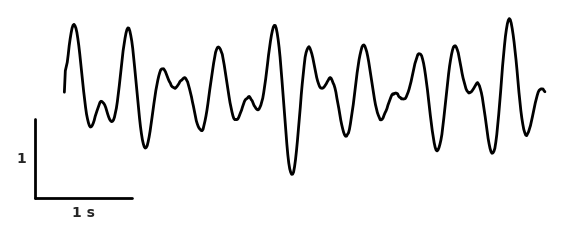

In [5]:

fs = 100
t = np.arange(N) / fs
n_show = 500

fig, ax = plt.subplots(1, 1, figsize=(6, 2.5))
ax.plot(t[:n_show], x_ar2_lo[:n_show], lw=2, color="black")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

x_bar_start, x_bar_end = -0.3, 0.7
y_min = x_ar2_lo[:n_show].min()
y_bar_bot = y_min - 0.3
y_bar_top = y_bar_bot + 1.0

ax.plot([x_bar_start, x_bar_end], [y_bar_bot, y_bar_bot], color="black", lw=2, clip_on=False)
ax.text((x_bar_start + x_bar_end) / 2, y_bar_bot - 0.1, "1 s", ha="center", va="top", fontsize=10, fontweight="bold")
ax.plot([x_bar_start, x_bar_start], [y_bar_bot, y_bar_top], color="black", lw=2, clip_on=False)
ax.text(x_bar_start - 0.1, (y_bar_bot + y_bar_top) / 2, "1", ha="right", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


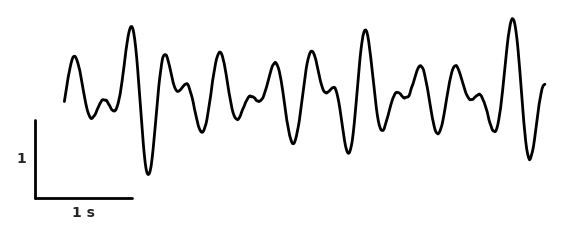

In [6]:

fig, ax = plt.subplots(1, 1, figsize=(6, 2.5))
ax.plot(t[:n_show], x_ar4_lo[:n_show], lw=2, color="black")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

x_bar_start, x_bar_end = -0.3, 0.7
y_min = x_ar4_lo[:n_show].min()
y_bar_bot = y_min - 0.3
y_bar_top = y_bar_bot + 1.0

ax.plot([x_bar_start, x_bar_end], [y_bar_bot, y_bar_bot], color="black", lw=2, clip_on=False)
ax.text((x_bar_start + x_bar_end) / 2, y_bar_bot - 0.1, "1 s", ha="center", va="top", fontsize=10, fontweight="bold")
ax.plot([x_bar_start, x_bar_start], [y_bar_bot, y_bar_top], color="black", lw=2, clip_on=False)
ax.text(x_bar_start - 0.1, (y_bar_bot + y_bar_top) / 2, "1", ha="right", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


In [14]:
SURFACE_COLOR = '#888888'
SURFACE_ALPHA = 0.55

def _clean_ax(ax, lim):
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor((1, 1, 1, 0))
        axis.line.set_color('k')
        axis.line.set_linewidth(0.6)
    ax.grid(False)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xlabel(r"$x(t)$", fontsize=11, labelpad=-10)
    ax.set_ylabel(r"$x(t-\tau)$", fontsize=11, labelpad=-10)
    ax.set_zlabel(r"$x(t-2\tau)$", fontsize=11, labelpad=-10)

def _legend_text(fit):
    return (
        f"$R^2 = {fit['r_squared']:.3f}$\n"
        f"Torus score $= {fit['frac_inside']:.3f}$\n"
        f"Torus error $= {fit['mean_error']:.4f}$"
    )

def plot_one_torus(ax, pts, fit):
    c = fit['center']; u = fit['u_axis']; v = fit['v_axis']
    R1o, R2o = fit['R1'], fit['R2']
    R1i, R2i = fit['R1_in'], fit['R2_in']
    lim = (np.linalg.norm(c) + max(R1o, R2o)) * 1.3
    phi_s = np.linspace(0, 2*np.pi, 100)
    t_s = np.linspace(0, 1, 15)
    PHI, T = np.meshgrid(phi_s, t_s)
    R1 = R1i + T*(R1o - R1i); R2 = R2i + T*(R2o - R2i)
    bx = R1*np.cos(PHI); by = R2*np.sin(PHI)
    X = c[0]+bx*u[0]+by*v[0]; Y = c[1]+bx*u[1]+by*v[1]; Z = c[2]+bx*u[2]+by*v[2]
    ax.plot(pts[:,0], pts[:,1], pts[:,2], 'k-', lw=0.4, alpha=0.8)
    ax.plot_surface(X, Y, Z, color=SURFACE_COLOR, alpha=SURFACE_ALPHA,
                    shade=True, edgecolor='none', linewidth=0, antialiased=True)
    _clean_ax(ax, lim)
    ax.text2D(0.02, 0.96, _legend_text(fit), transform=ax.transAxes,
              fontsize=8.5, verticalalignment='top', family='monospace',
              bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.8))

def plot_two_torus(ax, pts, fit):
    c = fit['center']; u = fit['u_axis']; v = fit['v_axis']; n = fit['direction']
    R1, R2, r = fit['R1'], fit['R2'], fit['minor_radius']
    lim = (np.linalg.norm(c) + max(R1, R2) + r) * 1.3
    phi = np.linspace(0, 2*np.pi, 100); theta = np.linspace(0, 2*np.pi, 15)
    PHI, THETA = np.meshgrid(phi, theta)
    bx = R1*np.cos(PHI); by = R2*np.sin(PHI)
    den = np.sqrt((R2*np.cos(PHI))**2+(R1*np.sin(PHI))**2)+1e-12
    ou = R2*np.cos(PHI)/den; ov = R1*np.sin(PHI)/den
    X = c[0]+bx*u[0]+by*v[0]+r*np.cos(THETA)*(ou*u[0]+ov*v[0])+r*np.sin(THETA)*n[0]
    Y = c[1]+bx*u[1]+by*v[1]+r*np.cos(THETA)*(ou*u[1]+ov*v[1])+r*np.sin(THETA)*n[1]
    Z = c[2]+bx*u[2]+by*v[2]+r*np.cos(THETA)*(ou*u[2]+ov*v[2])+r*np.sin(THETA)*n[2]
    ax.plot(pts[:,0], pts[:,1], pts[:,2], 'k-', lw=0.4, alpha=0.8)
    ax.plot_surface(X, Y, Z, color=SURFACE_COLOR, alpha=SURFACE_ALPHA,
                    shade=True, edgecolor='none', linewidth=0, antialiased=True)
    _clean_ax(ax, lim)
    ax.text2D(0.02, 0.96, _legend_text(fit), transform=ax.transAxes,
              fontsize=8.5, verticalalignment='top', family='monospace',
              bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.8))


In [32]:
tau = 9
m = 3

pts_ar2_lo = np.asarray(embed(x_ar2_lo, m, tau))
pts_ar2_hi = np.asarray(embed(x_ar2_hi, m, tau))
pts_ar4_lo = np.asarray(embed(x_ar4_lo, m, tau))
pts_ar4_hi = np.asarray(embed(x_ar4_hi, m, tau))

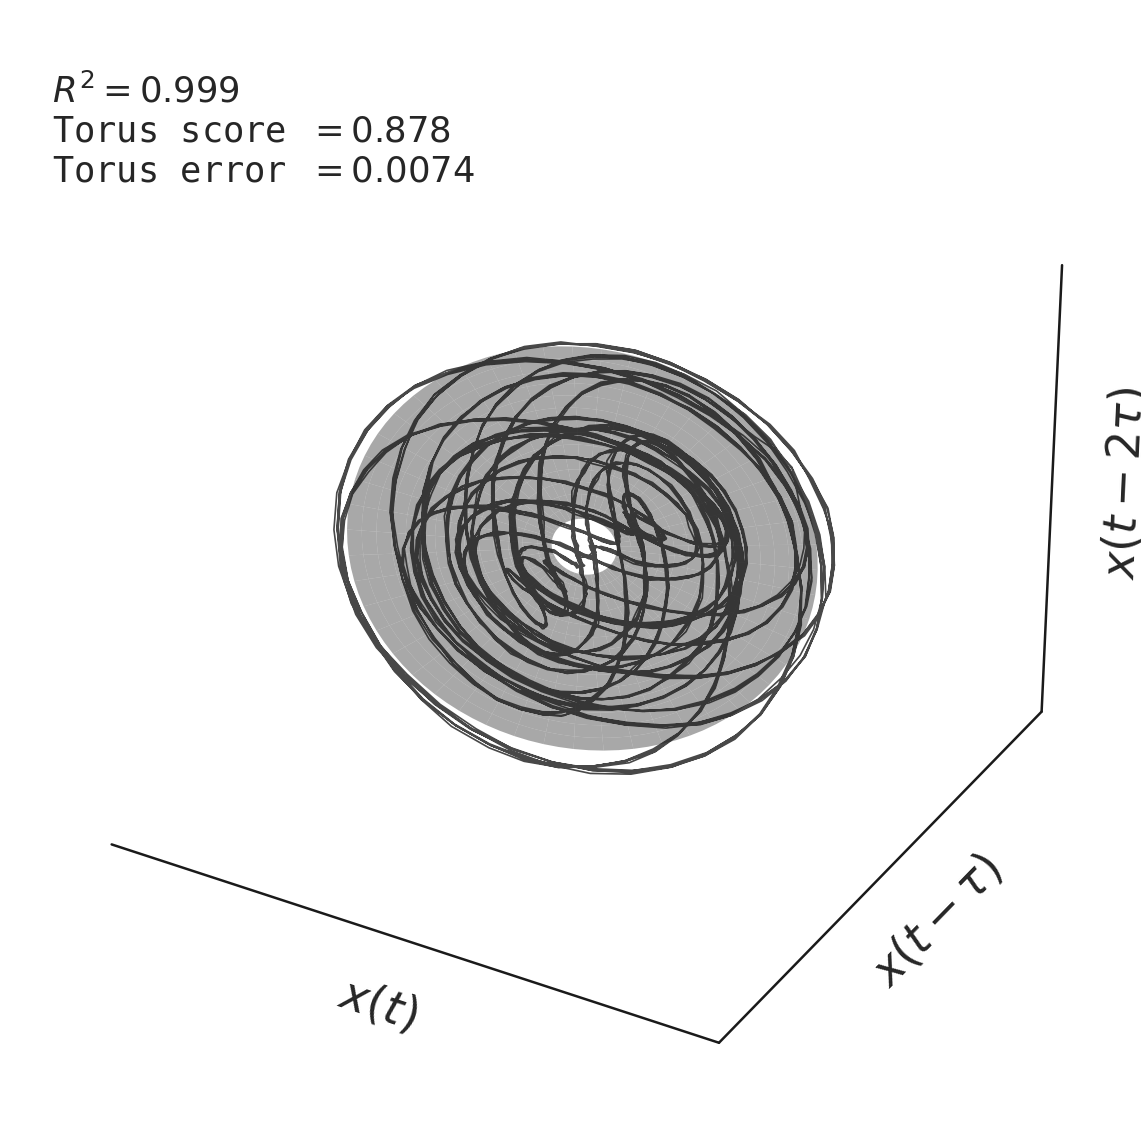

In [31]:
fit = one_torus_fit(pts_ar2_lo, lam=.1, hole_ratio=0.2)
fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection='3d')
plot_one_torus(ax, pts_ar2_lo, fit)
plt.tight_layout()


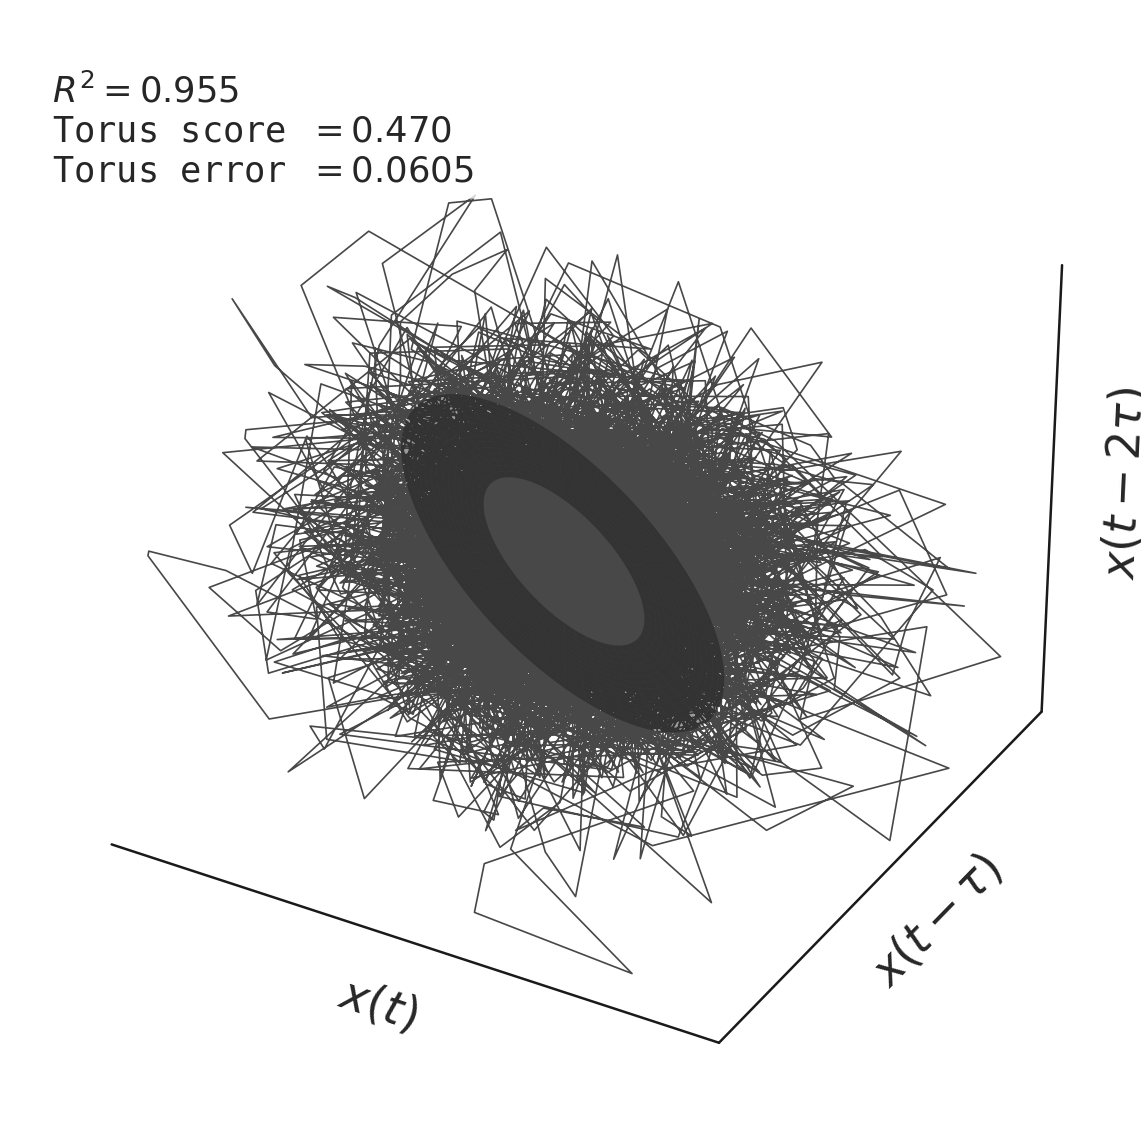

In [10]:
fit = one_torus_fit(pts_ar2_hi, lam=1.0, hole_ratio=0.5)
fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection='3d')
plot_one_torus(ax, pts_ar2_hi, fit)
plt.tight_layout()


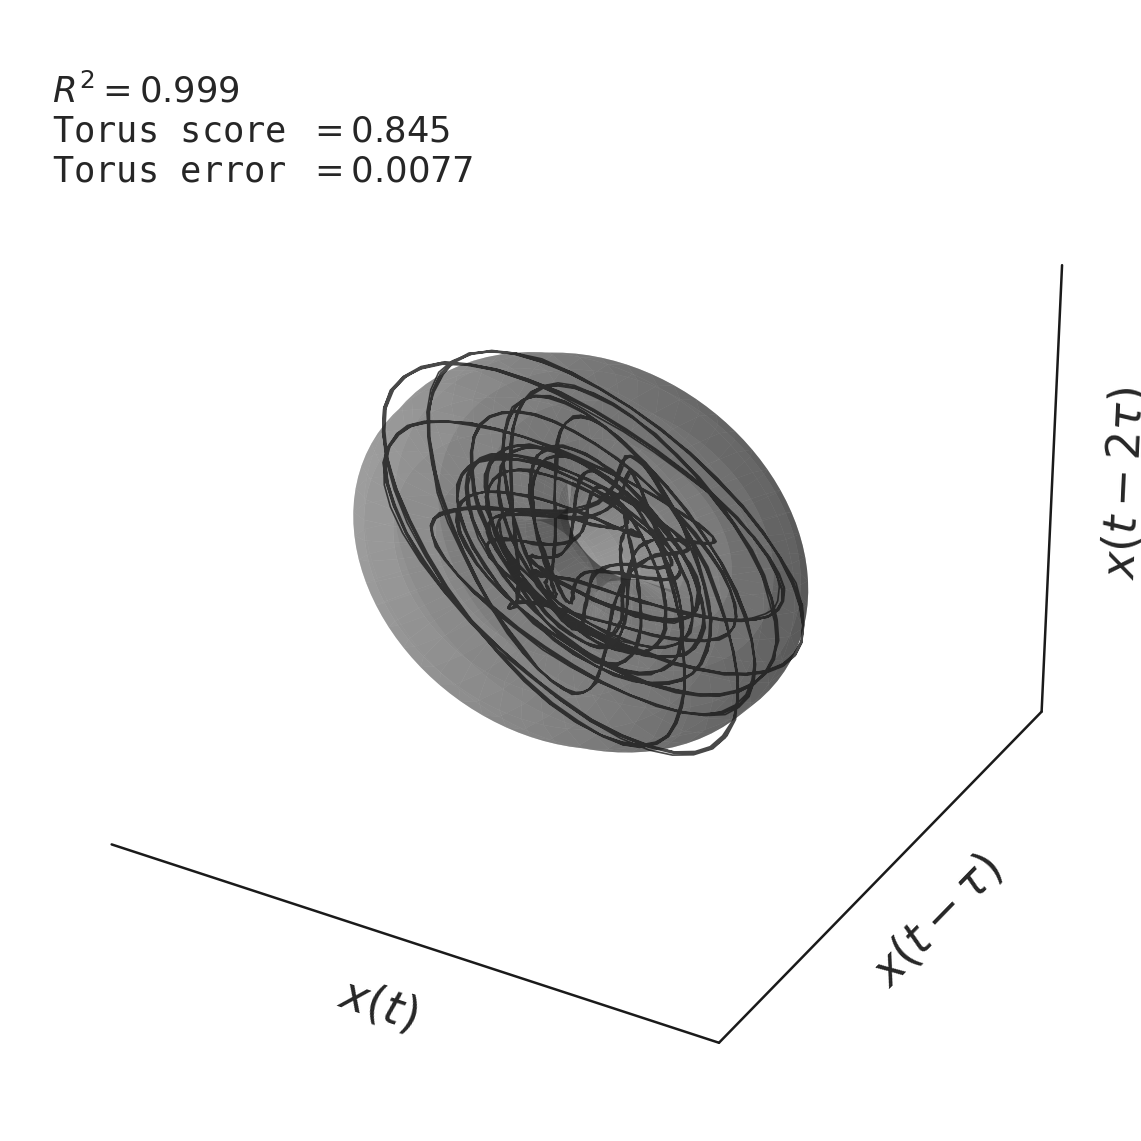

In [11]:
fit = two_torus_fit(pts_ar4_lo, lam=0.05, hole_ratio=0.1)
fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection='3d')
plot_two_torus(ax, pts_ar4_lo, fit)
plt.tight_layout()


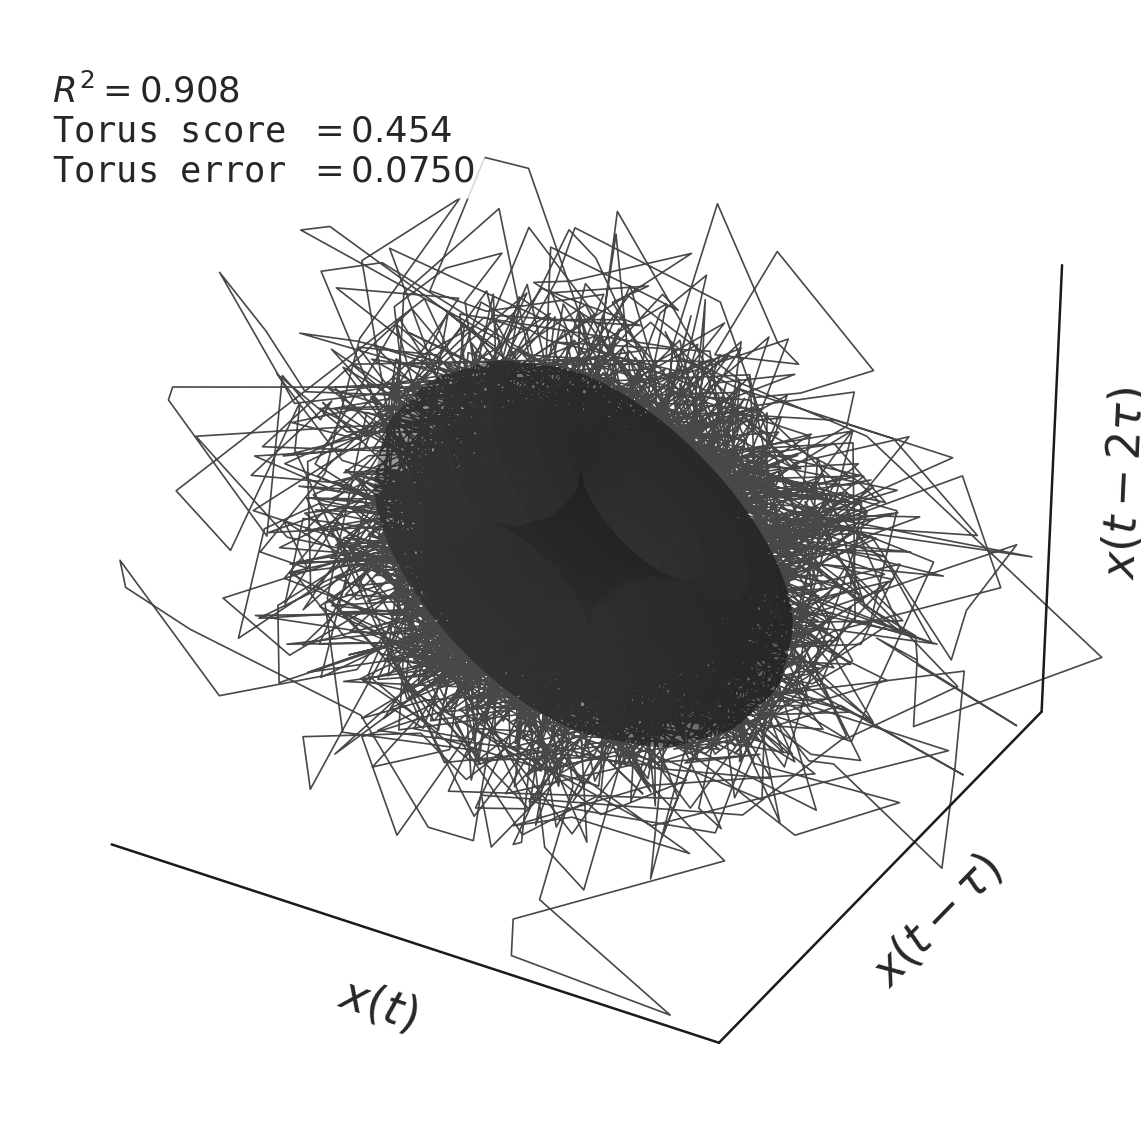

In [12]:
fit = two_torus_fit(pts_ar4_hi, lam=1.0, hole_ratio=0.75)
fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111, projection='3d')
plot_two_torus(ax, pts_ar4_hi, fit)
plt.tight_layout()
